In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import src.features as features # pyright: ignore[reportMissingImports]

from config import PROCESSED_DATA # pyright: ignore[reportMissingImports]

In [2]:
test_data_eval = pd.read_parquet(PROCESSED_DATA / 'cat_test_data_eval.parquet')

In [3]:
test_data_eval.head(2)

,StockCode,InvoiceDate,Quantity,Revenue,lag_1w_qty,lag_2w_qty,lag_4w_qty,lag_8w_qty,lag_12w_qty,rolling_mean_4w_qty,...,rolling_std_4w_qty,trend_ratio,rolling_cv_qty,sin_week,cos_week,is_q4,is_december,days_to_christmas,naive_pred,predicted_qty
45,15036,2011-10-24,111,104.13,249.0,687.0,93.0,60.0,677.0,288.75,...,273.854432,0.969231,0.948414,-0.885456,0.464723,1,0,62,249.0,155.665933
46,15036,2011-10-31,112,105.76,111.0,249.0,126.0,181.0,912.0,293.25,...,269.681757,1.169492,0.919631,-0.822984,0.568065,1,0,55,111.0,110.505655


In [4]:
# Forecast error std per product
test_data_eval["forecast_error"] = test_data_eval["Quantity"] - test_data_eval["predicted_qty"]
test_data_eval["demand_std"] = test_data_eval.groupby("StockCode", observed=True)["forecast_error"].transform("std")

In [5]:
# Keeping only the relevant columns for inventory optimization analysis
columns_to_use = ['StockCode', 'InvoiceDate', 'Quantity', 'predicted_qty', 'demand_std' ]

test_data_eval = test_data_eval[columns_to_use]

In [6]:
# Calculating safety stock using the demand standard deviation and a service level factor (e.g., 1.65 for 95% service level)
LEAD_TIME_WEEKS = 1 # Assuming a lead time of 1 week for simplicity
Z = 1.65 # Z-score for 95% service level

test_data_eval["safety_stock"] = Z * test_data_eval["demand_std"] * np.sqrt(LEAD_TIME_WEEKS)

In [7]:
# Calculating the reorder point by adding the predicted quantity and the safety stock
test_data_eval["reorder_point"] = (test_data_eval["predicted_qty"] * LEAD_TIME_WEEKS) + test_data_eval["safety_stock"]

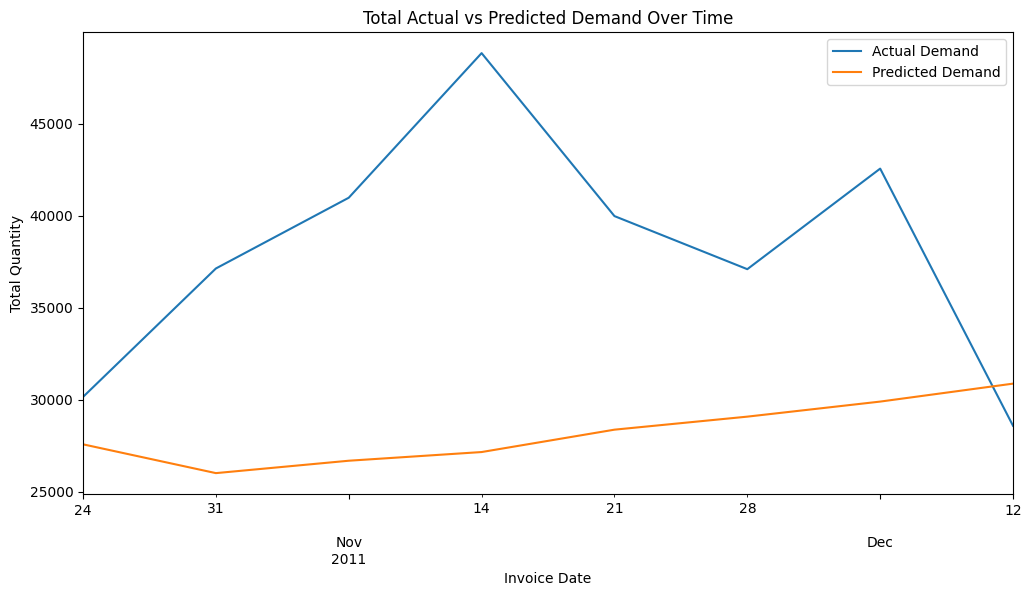

In [9]:
# Visualizing total actual vs predicted demand over time
test_data_eval.groupby("InvoiceDate")[["Quantity", "predicted_qty"]].sum().plot(figsize=(12, 6))
plt.title("Total Actual vs Predicted Demand Over Time")
plt.xlabel("Invoice Date")
plt.ylabel("Total Quantity")
plt.legend(["Actual Demand", "Predicted Demand"])
plt.show()

In [10]:
stats_per_product = test_data_eval.groupby("StockCode", observed=True).agg(
    total_predicted_demand=pd.NamedAgg(column="predicted_qty", aggfunc="sum"),
    total_actual_demand=pd.NamedAgg(column="Quantity", aggfunc="sum"),
    average_safety_stock=pd.NamedAgg(column="safety_stock", aggfunc="mean"),
    average_reorder_point=pd.NamedAgg(column="reorder_point", aggfunc="mean")
).reset_index()

In [ ]:
# Identifying top 10 products by total actual demand
top_10_products = stats_per_product.sort_values("total_actual_demand", ascending=False).head(10)

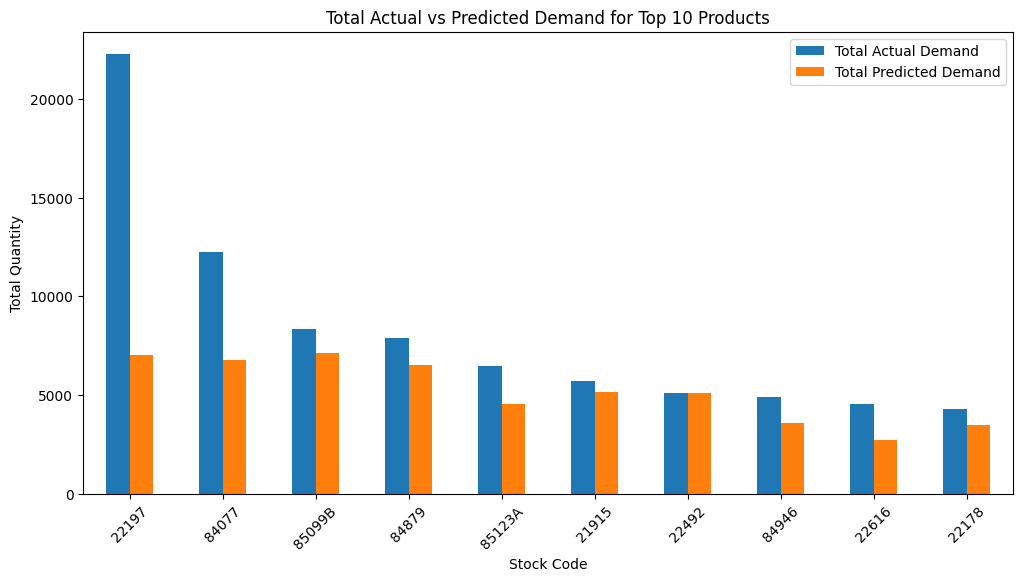

In [13]:
# Visualizing total actual vs predicted demand for top 10 products
top_10_products.plot(figsize=(12, 6), x="StockCode", y=["total_actual_demand", "total_predicted_demand"], kind="bar")
plt.title("Total Actual vs Predicted Demand for Top 10 Products")
plt.xlabel("Stock Code")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.legend(["Total Actual Demand", "Total Predicted Demand"])
plt.show()

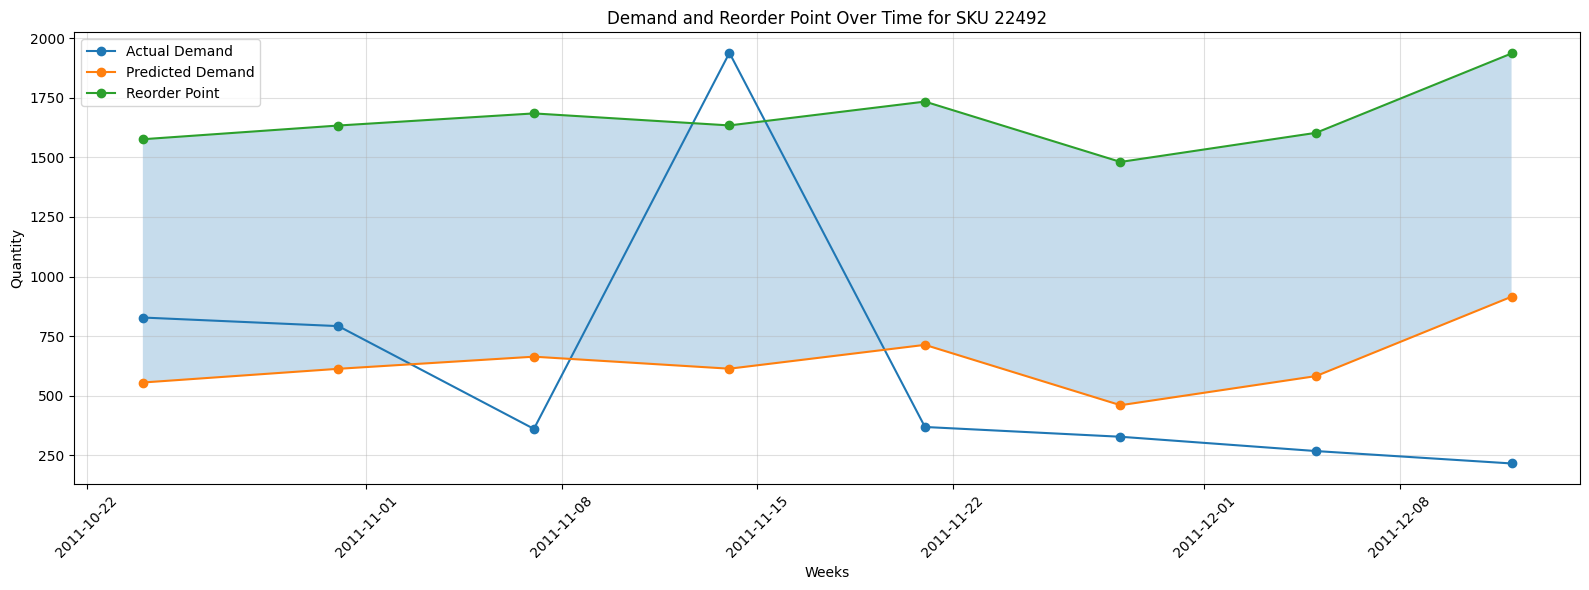

In [22]:
# Visualizing demand and reorder point over time for a specific SKU
sku = "22492" # SKU with typical demand pattern for visualization

sku_df = test_data_eval[test_data_eval["StockCode"] == sku].sort_values("InvoiceDate")

plt.figure(figsize=(16, 6))

plt.plot(sku_df["InvoiceDate"], sku_df["Quantity"], label="Actual Demand", marker="o")
plt.plot(sku_df["InvoiceDate"], sku_df["predicted_qty"], label="Predicted Demand", marker="o")
plt.plot(sku_df["InvoiceDate"], sku_df["reorder_point"], label="Reorder Point", marker="o")

plt.fill_between(
    sku_df["InvoiceDate"],
    sku_df["predicted_qty"],
    sku_df["reorder_point"],
    alpha=0.25
)

plt.title(f"Demand and Reorder Point Over Time for SKU {sku}")
plt.legend()
plt.grid(True, alpha=0.4)
plt.xlabel("Weeks")
plt.ylabel("Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Given no inventory data, this model provides demand forecasts and recommended reorder points. Inventory status decisions require integration with a stock management system.